# 1. Прогноз на 7 дней

## IMPORTS

In [26]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from arch import arch_model
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

## CONSTANTS

In [2]:
START = "2017-01-01" 
END = datetime.now().strftime("%Y-%m-%d")
TARGET_HORIZON = 7 # горизонт прогноза - 7 торговых дней
TARGET = "Brent_7d"
INITIAL_TRAIN_YEARS = 5 # сколько лет используется для обучения Light GBM
REFIT_FREQ = 21
FEATURES = {"Brent": "BZ=F", "WTI": "CL=F", "DXY": "DX-Y.NYB",
    "VIX": "^VIX", "US10Y": "^TNX", "Copper": "HG=F", "SPY": "SPY", "XLE": "XLE"}

Пояснения к выбранным переменным: 

1) Начало данных с 2017 года было взято по следующим причинам: 

* Изменения состава экспортеров: до 2015 США были импортером, в декабре 2015 был отменен 40 летний запрет на экспорт нефти - США постепенно стали наращивать экспорт нефти. Появление такого игрока с отличающейся от ОПЕК себестоимостью изменило спрос-предложение на рынке
* 2014-2016 - ценовая война Саудовской Аравии против американской сланцевой добычи- ановмальная волатильность на рынке из за переизбытка сланцевой добычи США
* в декабре 2016 - подписание договора ОПЕК+ и контроль над примерно 50% мировой добычи (до этого ОПЕК в одиночку с долей около 30% не мог контролировать цену в условиях растущей сланцевой добычи США)

Поэтому до начала 2017 обучающая выборка будет относиться к другому режиму рынка и скорее окажет негативное влияение на объясняющую способность модели

2) REFIT_FREQ = 21

Для того, чтобы модель адаптировалась к режимам рынка я применяю walk-forward валидацию с рефитом раз в 21 торговый день (ежедневный рефит избыточен, так как дневные данные сликшом волатильны и не изменят модель, при этом время обучения значительно увеличится, рефит раз в год сделает модель отстающей от текущей рыночной ситауации).
При каждом рефите модель обучается с нуля на всех данных от начала выборки до текущего дня (расширяющееся окно).
Я беру расширяющееся окно, потому что оно накапливает больше данных. Скользящее окно более чувствительно к режимным сдвигам, но рискует "забыть" паттерны (скользящее окно выкинет паттерн COVID и 2022 года, а это важно помнить для обучения модели реагировать на шоки)

3) Выбор переменных:
* "Brent" - целевая
* "WTI" - добавлен в выборку для создания переменной спреда к Brent, так как он содержит информацию 1) о геополитической премии (Brent - чувствителен к ситуации на Ближнем Востоке, России, Северной Африки, WTI менее чувствителен из-за более слабой связи на уровне логистики, поэтому при геополитических кризисах в этих регионах спред будет расширяться), 2) данных об экспорте в США через логистические показатели (переполнение  нефти в хранилищах США ведет к удешевлению WTI относительно Brent и росту спреда)
То есть, это впередсмотрящий индикатор, так как отражает изменения рыночных условий быстрее чем абсолютная цена. В коде это реализовано через три фичи (спред, его изменение, отношение Brent/WTI).
* "DXY" - курс доллара (при увеличении из-за сокращения спроса импортеров цена падает, также отражает стрессовые периоды (укрепление доллара - снижение цены Brent))
* "VIX" вмененная волатильность S&P 500 на 30 дней вперёд из цен опционов, важен как индикатор риска. При низком VIX риск активы будут расти, при высоком - ротация в Treasuries, доллар - цены на сырье падают. Это впередсмотрящий индикатор.
* "US10Y" - доходность 10 летних Treasuries исплльзуем как индикатор долгосрочного роста экономики, инфляции. Кроме того, является бенчмарком безрисковой ставки. При росте доходностей из-за ожиданий роста инфляции нефть может использоваться как хеджирующий актив - Brent растет 2) при падении из-за ротации из рисковых активов - падение Brent. В случаях цикла смягчения/ужесточения политики ФРС динамика будет разнонаправленная - смягчение - снижение доходностей - рост Brent и наоборот при ужесточении. Однако такие режимы будут ловиться LightGBM через VIX и DXY, так как дерево будет составлять правила вида: рост VIX + падение US10Y - индикатор стресса, снижение VIX + снижение US10Y - индикатор цикла смягчения ДКП итд
* "Copper" - индикатор промышленного спроса. Ожидается одинаковое направление движения у меди и нефти
* "SPY" - ETF, отслеживающий динамику S&P 500 - индикатор широкого рынка
* "XLE" - ETF, отслеживающий динанмику крупнейших энергетических компаний - содержит ожидания инвесторов от нефтегазовых компаний

In [3]:
raw_data = yf.download(list(FEATURES.values()),start = START, end=END, auto_adjust=False, progress=False)["Close"]
raw_data = raw_data.rename(columns={v: k for k, v in FEATURES.items()})
df = raw_data.ffill().dropna()
df.head()

Ticker,Brent,WTI,DXY,Copper,SPY,XLE,US10Y,VIX
Date,,,,,,,,
2017-01-03,55.470001,52.330002,103.209999,2.4810,225.240005,38.084999,2.450,12.85
2017-01-04,56.459999,53.259998,102.699997,2.5480,226.580002,38.005001,2.452,11.85
2017-01-05,56.889999,53.759998,101.519997,2.5295,226.399994,37.910000,2.368,11.67
2017-01-06,57.099998,53.990002,102.220001,2.5380,227.210007,37.945000,2.418,11.32
2017-01-09,54.939999,51.959999,101.930000,2.5300,226.460007,37.395000,2.376,11.56


## FEATURE ENGINEERING

In [4]:
feat = pd.DataFrame(index=df.index)

In [5]:
# Переводим в вид доходностей для стационарности рядов
for col in df.columns:
    feat[f"{col}_ret"] = df[col].pct_change()

# Лаги
for lag in [1, 2, 3, 5, 10]:
    feat[f"Brent_ret_lag{lag}"] = feat["Brent_ret"].shift(lag)

# Моментум
for window in [5, 10, 20, 60]:
    feat[f"Brent_mom_{window}"] = df["Brent"].pct_change(window)

# Волатильность через стандартное отклонение
for window in [5, 20]:
    feat[f"Brent_rv_{window}"] = feat["Brent_ret"].rolling(window).std()

# RSI
def rsi(series, n=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(n).mean()
    loss = -delta.clip(upper=0).rolling(n).mean()
    rs = gain / (loss + 1e-10)
    return 100 - 100 / (1 + rs)

feat["Brent_rsi14"] = rsi(df["Brent"], 14)

# MACD
ema12 = df["Brent"].ewm(span=12, adjust=False).mean()
ema26 = df["Brent"].ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
signal_line = macd_line.ewm(span=9, adjust=False).mean()
feat["Brent_macd"] = macd_line - signal_line

# Brent-WTI spread 
feat["BrentWTI_spread"] = df["Brent"] - df["WTI"]
feat["BrentWTI_spread_chg"] = feat["BrentWTI_spread"].diff()
feat["BrentWTI_ratio"] = df["Brent"] / df["WTI"]

# Lag всех фичей на 1 день - фичи доступны на закрытии t-1
feat = feat.shift(1)

# Target
feat["Brent_7d"] = df["Brent"].shift(-TARGET_HORIZON) / df["Brent"] - 1
feat = feat.dropna()

Отдельно введем GARCH(1, 1) - фичу для прогнозирования волатильности на TARGET_HORIZON дней вперед. GARCH берем walk forward, то есть переобучаем модель на новых данных, чтобы не использовать устаревшие данные для прогноза. В модели используется p = 1, q = 1 для снижения склонности к переобучению, проклятья размерности (в нашей выборке и так не очень много данных). Кроме того, добавление большего количество лаговых переменных редко показывают значительное улучшение, однако сильно увеличивают сложность модели.

In [6]:
def compute_garch(returns, refit_freq=REFIT_FREQ, horizon=TARGET_HORIZON, min_history=500):
    out = pd.Series(index=returns.index, dtype=float)
    r_pct = returns.dropna() * 100
    last_fit_idx = -refit_freq # счётчик когда последний раз обучали модель
    model_res = None
    
    for i in range(min_history, len(r_pct)): # начинаем с min_history чтобы было достаточно данных для первого fit
        
        if i - last_fit_idx >= refit_freq: # рефит раз в refit_freq дней
            # здесь я использую распределение Стьюдента, для того чтобы учесть тяжелые хвосты
            # использовать нормальное распределение было бы слишком сильным упрощением особенно для кризисных периодов
            # при этом для t распределения есть риск, что модель не сойдется, потому что модель оценивает количество степеней свободы вместе с коэффициентами GARCH
            # в нашем случае эмпирически модель сходится
            am = arch_model(r_pct.iloc[:i], vol="GARCH", p=1, q=1,  mean="Zero", dist="t")
            model_res = am.fit(disp="off", show_warning=False)
            last_fit_idx = i
        f = model_res.forecast(horizon=horizon, reindex=False)
        
        var_h = f.variance.values[-1, :].sum()
        out.iloc[i] = np.sqrt(var_h) / 100 # переводим обратно в доли
    
    return out

In [7]:
brent_returns = df["Brent"].pct_change()
garch_vol = compute_garch(brent_returns)

# фича доступна только с задержкой в 1 день (для исключения look-ahead bias)
feat["garch_vol_7d"] = garch_vol.shift(1)
feat = feat.dropna()

## BASELINE

In [8]:
def get_lgbm(objective, alpha=None):
    params = dict(
        n_estimators=300, max_depth=4, learning_rate=0.03,
        min_child_samples=30, subsample=0.8, colsample_bytree=0.7,
        random_state=42, verbose=-1,
    )
    if objective == "regression":
        return LGBMRegressor(objective="regression", **params)
    elif objective == "huber":
        return LGBMRegressor(objective="huber", alpha=0.05, **params)
    elif objective == "quantile":
        return LGBMRegressor(objective="quantile", alpha=alpha, **params)

В модели я используют Light GBM. 

1) я не использую Cat boost по причине того, что он силен на категориальных переменных - за счёт их обработки через target encoding. Однако у нас таких нет, поэтому здесь использование такой модели избыточно и не снизит ошибку. Как и CatBoost Light GBM использует механизмы предотвращения переобучения 

Почему я не добавила категориальные переменные, например, разметкой "кризис - не кризис": я считаю, что это look ahead bias, так как завершение кризиса будет задано мной "руками", что негативно повлияет на модель. Связывать периоды кризиса с конкретными переменными (например, VIX - было бы дублированием и не добавило информации)

2) Я не использую Random Forest из-за метода построения деревьев этой модели (в теории модели градиентного бустинга считаются более совершенными): в отличие от Random Forest, которая на случайных подвыборках строит дереьвя и делает финальное предсказание как среднее из результатов (на наших данных, где горизонт очень краткосрочен, а также высокая волатильность такое усреднение я считаю ошибкой), бустинги последовательно обучают деревья, исправляя ошибки предыдущих деревьев, а затем динамически взвешивают данные (те, где были допущены ошибки получают больший вес)

3) Я не использую линейные модели с регуляризацией даже в качестве baseline в силу нелинейности связей между выбранными фичами. Хоть регуляризация используется чтобы решить проблему мультиколлинеарности в ванильных линейных моделях, алгоритм деревьев в целом не страдает проблемой мультиколлинеарности

4) Я не использую модель XGBoost, так как он менее совершенен Light GBM в плане борьбы с переобучением

5) Я не использую агентные архитектуры для построения прогнозов, так как 1) модели могут быть обучены на данных до конфликта, 2) вероятны разные ответы при повторных запусках 3) с точки зрения ресурсов использования API точечные предсказания чрезмерно затратны 

In [27]:
features = [c for c in feat.columns if c != TARGET]
start_date = feat.index[0] + pd.DateOffset(years=INITIAL_TRAIN_YEARS) # ищем индекс старта теста
test_start_idx = (feat.index >= start_date).argmax()

preds = []
active_models = {}
arima_pred = 0.0

for i in range(test_start_idx, len(feat) - TARGET_HORIZON):
    curr_date = feat.index[i]
    
    # Рефит моделей - если кратно 21 
    if (i - test_start_idx) % REFIT_FREQ == 0:
        train = feat.iloc[:i - TARGET_HORIZON] # отступ назад, чтобы не было look ahead bias
        X_tr, y_tr = train[features], train[TARGET]

        active_models = {
            "mse": get_lgbm("regression").fit(X_tr, y_tr),
            "huber": get_lgbm("huber").fit(X_tr, y_tr),
            "q50": get_lgbm("quantile", 0.5).fit(X_tr, y_tr),
            "q10": get_lgbm("quantile", 0.1).fit(X_tr, y_tr),
            "q90": get_lgbm("quantile", 0.9).fit(X_tr, y_tr),
        }

        # Бэйзлайн ARIMA
        brent_1d = df["Brent"].pct_change().loc[:feat.index[i-1]].dropna()
        arima_fit = ARIMA(brent_1d.tail(500), order=(1, 0, 1)).fit()
        arima_pred = float(arima_fit.forecast(steps=7).sum())

    # Прогноз
    x_t = feat[features].iloc[[i]]
    row = {"date": curr_date, "y_true": feat[TARGET].iloc[i], "naive": feat["Brent_mom_5"].iloc[i], "arima": arima_pred}
    
    # Предикты ML моделей
    for name, model in active_models.items():
        row[name] = model.predict(x_t)[0]
        
    preds.append(row)

results = pd.DataFrame(preds).set_index("date")

## METRICS

In [10]:
def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # бэктестинг
    nz = np.abs(y_pred) > 0.000000000001 # маска ненулевых предсказанйи
    da = np.mean(np.sign(y_true[nz]) == np.sign(y_pred[nz])) # доля случаев когда модель угадала знак
    pos = np.sign(y_pred) # направление предсказания
    strat = pos * y_true # реализованная доходность
    sharpe = (np.mean(strat) / np.std(strat)) * np.sqrt(52) if np.std(strat) > 0 else np.nan # sharpe

    return rmse, mae, da, sharpe

In [11]:
results["snr"] = results["q50"].abs() / (results["q90"] - results["q10"] + 0.000000000001) # отношение сигнал - шум

metrics = pd.DataFrame(
    {name: evaluate(results["y_true"], results[col])
     for name, col in [("naive", "naive"),
         ("arima", "arima"),
         ("mse", "mse"),
         ("huber", "huber"),
         ("q50", "q50")]}, index=["RMSE", "MAE", "DirAcc", "Sharpe"]).T.round(5)

print(metrics)

          RMSE      MAE   DirAcc   Sharpe
naive  0.07688  0.05712  0.43056 -0.44537
arima  0.05848  0.03983  0.47405 -0.29044
mse    0.06113  0.04097  0.57612  0.34664
huber  0.06152  0.04139  0.55536  0.10324
q50    0.06068  0.04087  0.57785  0.38837


In [12]:
def snr_metrics(pct):
    mask = results["snr"] >= np.percentile(results["snr"], 100 - pct)
    rmse, mae, da, sh = evaluate(results.loc[mask, "y_true"], results.loc[mask, "q50"])
    return {"n_trades": mask.sum(), "dir_acc": da, "sharpe": sh}

snr_table = pd.DataFrame({f"top_{p}%": snr_metrics(p) for p in [100, 50, 30, 20, 10] if snr_metrics(p)}).T.round(3)
print(snr_table)

          n_trades  dir_acc  sharpe
top_100%     578.0    0.578   0.388
top_50%      289.0    0.626   1.069
top_30%      174.0    0.655   0.973
top_20%      116.0    0.638   0.274
top_10%       58.0    0.603  -0.357


## FEATURE IMPORTANCE

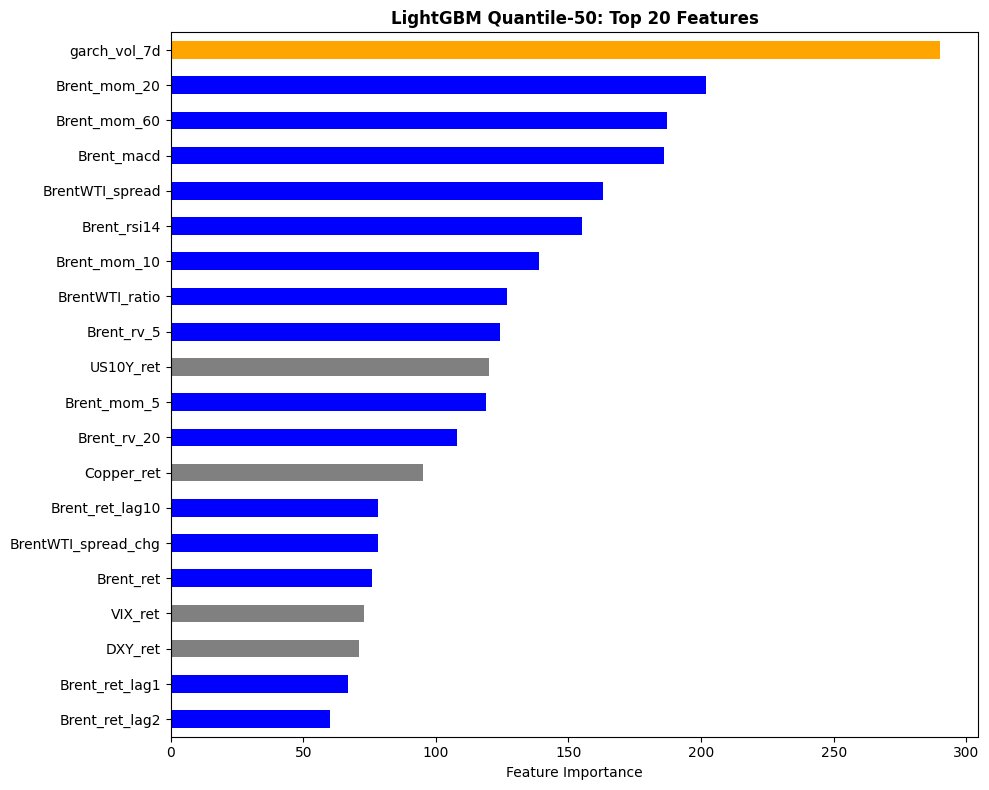

In [13]:
features = [c for c in feat.columns if c != TARGET]
imp = pd.Series(active_models["q50"].feature_importances_, index=features).sort_values()
top20 = imp.tail(20)

bar_colors = [
    'blue' if 'Brent' in f 
    else 'red' if any(x in f for x in ['WTI', 'spread', 'ratio'])
    else 'orange' if 'garch' in f
    else 'grey'
    for f in top20.index
]

top20.plot.barh(figsize=(10, 8), color=bar_colors)
plt.xlabel("Feature Importance")
plt.title("LightGBM Quantile-50: Top 20 Features", fontweight='bold')
plt.tight_layout()
plt.show()

Очень сильное влияние оказывает GARCH фича, что говорит о огромном влиянии волатильности на краткосрочном горизонте.

In [14]:
features = [c for c in feat.columns if c != TARGET]
latest_features = feat[features].iloc[-1:]

brent_current_price = df["Brent"].iloc[-1]
brent_current_date = df.index[-1]

predictions = {}
for name, model in active_models.items():
    predictions[name] = model.predict(latest_features)[0]

target_date = brent_current_date + pd.Timedelta(days=7)

print(f"Текущая дата: {brent_current_date.date()}")
print(f"Целевая дата: {target_date.date()}")
print(f"Brent сейчас: ${brent_current_price:.2f}\n")

print("Модель    Цена")
for name in ["q10", "q50", "q90", "mse", "huber"]:
    ret = predictions[name]
    price = brent_current_price * (1 + ret)
    print(f"{name}   ${price:>7.2f}")

q10_price = brent_current_price * (1 + predictions["q10"])
q50_price = brent_current_price * (1 + predictions["q50"])
q90_price = brent_current_price * (1 + predictions["q90"])

print(f"Прогноз: ${q50_price:.2f}")
print(f"80% интервал: ${q10_price:.2f} - ${q90_price:.2f}")

# оценка сигнал/шум
direction = "up" if predictions["q50"] > 0 else "down"
ci_width = predictions["q90"] - predictions["q10"]
snr = abs(predictions["q50"]) / (ci_width + 1e-8)

print(f"Направление: {direction}, SNR = {snr:.2f}")

if snr > 0.4:
    conf = "high"
elif snr > 0.2:
    conf = "medium"
else:
    conf = "low"
print(f"Confidence: {conf}")

Текущая дата: 2026-05-07
Целевая дата: 2026-05-14
Brent сейчас: $100.06

Модель    Цена
q10   $  87.74
q50   $  99.73
q90   $ 109.72
mse   $  96.02
huber   $  96.79
Прогноз: $99.73
80% интервал: $87.74 - $109.72
Направление: down, SNR = 0.02
Confidence: low


In [15]:
def plot_forecast(df, results, year, step=3, horizon=7, figsize=(14, 7)):
    prices = df["Brent"]
    mask = prices.index.year == year
    prices_year = prices[mask]
    results_year = results[results.index.year == year]
    
    plt.figure(figsize=figsize)
    plt.plot(prices_year.index, prices_year.values, 'k-', linewidth=1.5, alpha=0.8, label='Brent actual')
    
    for dt in results_year.index[::step]:
        if dt not in prices.index:
            continue
        
        price_now = prices.loc[dt]
        pred = results_year.loc[dt, "q50"]
        price_future = price_now * (1 + pred)
        
        color = 'g' if pred > 0 else 'r'
        plt.plot([dt, dt + pd.Timedelta(days=horizon)], 
                [price_now, price_future], 
                color=color, alpha=0.4, linewidth=1)
    
    plt.xlabel('Дата')
    plt.ylabel('Brent')
    plt.title(f'Brent {year}: прогнозы на {horizon} дней')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

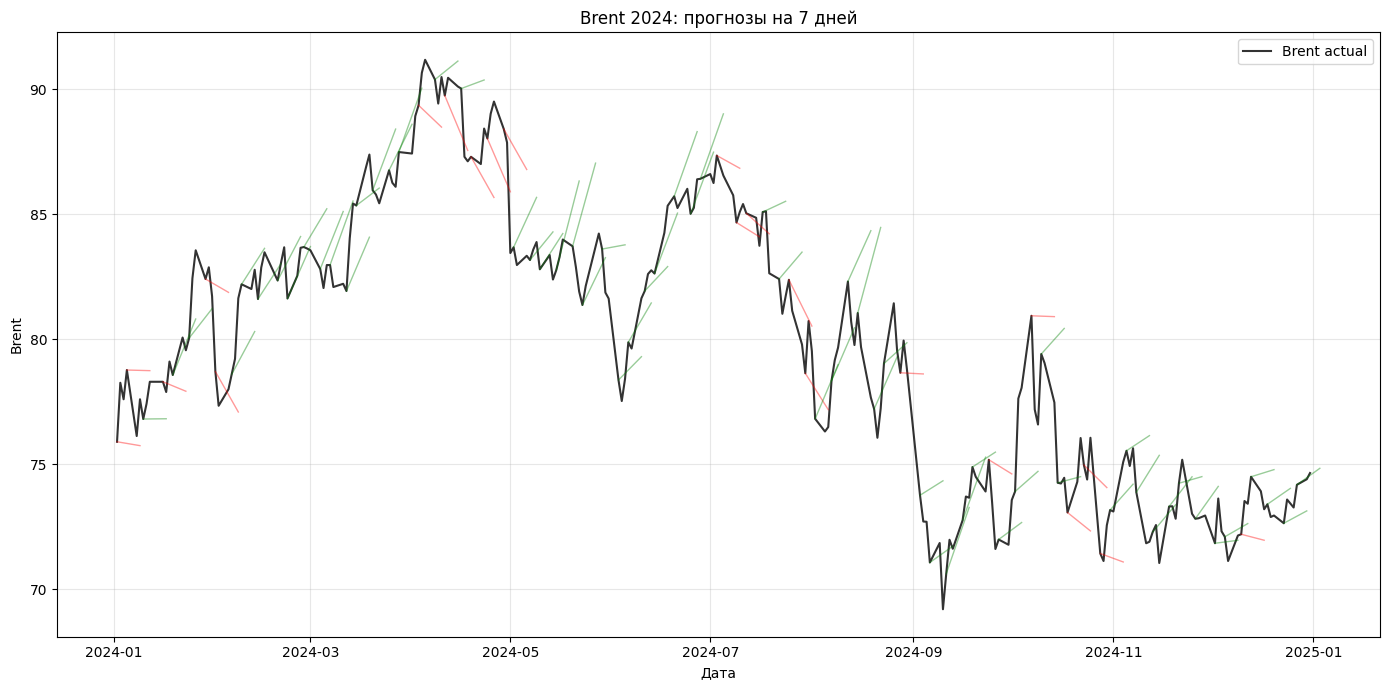

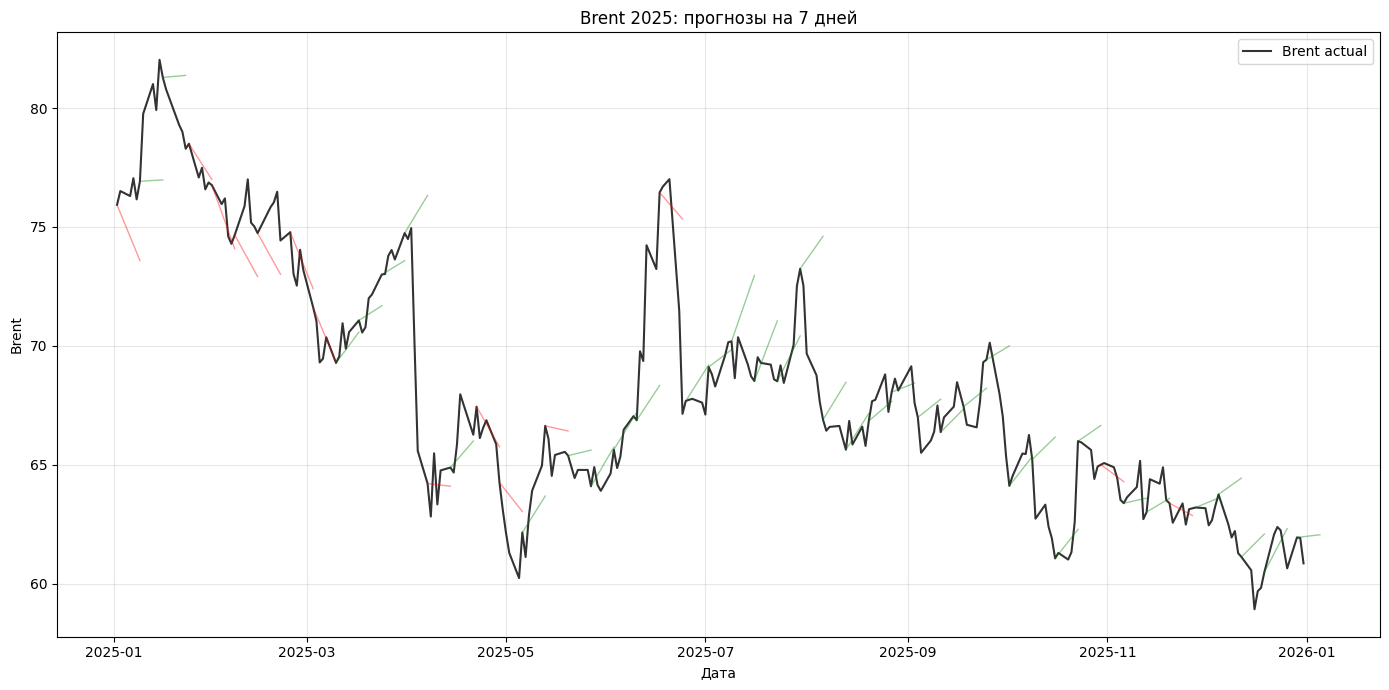

In [16]:
plot_forecast(df, results, year=2024)
plot_forecast(df, results, year=2025, step=5, horizon=7)

# 2. Прогноз до конца 2026 года

In [17]:
# Константы
TARGET_DATE = pd.Timestamp("2026-12-31")
N_SIMS = 10_000
BLOCK_SIZE = 20
SEED = 42

daily = df["Brent"].dropna()
monthly = daily.resample("ME").last().dropna()

last_date = daily.index[-1]
current_price = float(daily.iloc[-1])

Для прогноза до конца 2026 года я использовала метод block bootstrap, который в отличие от обычного он сохраняет волатильность, автокорреляции, кризисы, так как перемешивает блоки данных. При этом в отличие от обычных моделей временных рядов не требует знать распределения. Я использую блоки размером в 20 дней

In [18]:
def block_bootstrap_paths(daily_prices, target_date, block_size=20, n_sims=10000, seed=42):
    np.random.seed(seed)

    current_price = daily_prices.iloc[-1]
    last_date = daily_prices.index[-1]
    
    # лог доходности
    log_returns = np.log(daily_prices / daily_prices.shift(1)).dropna().values
    n_returns = len(log_returns)
    days_ahead = (target_date - last_date).days
    trading_days = int(days_ahead * 252 / 365) 
    
    n_blocks = trading_days // block_size + 1
    valid_starts = np.arange(n_returns - block_size + 1)
    
    paths = np.zeros((n_sims, trading_days))
    
    for i in range(n_sims):
        block_starts = np.random.choice(valid_starts, n_blocks, replace=True)
        
        path_returns = []
        for start in block_starts:
            path_returns.extend(log_returns[start:start + block_size])
        
        path_returns = np.array(path_returns[:trading_days])
        paths[i] = current_price * np.exp(np.cumsum(path_returns))
    
    path_dates = pd.bdate_range(
        start=last_date + pd.Timedelta(days=1), 
        periods=trading_days
    )
    
    return paths, path_dates

In [19]:
paths, path_dates = block_bootstrap_paths(daily, TARGET_DATE, block_size=BLOCK_SIZE, n_sims=N_SIMS, seed=SEED)
terminal_prices = paths[:, -1]

# Метрики
median = float(np.median(terminal_prices))
mean = float(np.mean(terminal_prices))
ci_80_low = float(np.percentile(terminal_prices, 10))
ci_80_high = float(np.percentile(terminal_prices, 90))
ci_95_low = float(np.percentile(terminal_prices, 2.5))
ci_95_high = float(np.percentile(terminal_prices, 97.5))

print(f"Текущая цена: ${current_price:.2f}")
print(f"Целевая дата: {TARGET_DATE.date()}")
print(f"Торговых дней: {paths.shape[1]}")
print(f"Block size: {BLOCK_SIZE} дней")
print(f"Симуляций: {N_SIMS:,}")
print()
print(f"Median: ${median:.2f}")
print(f"Mean: ${mean:.2f}")
print(f"80% CI: ${ci_80_low:.2f} - ${ci_80_high:.2f}")
print(f"95% CI: ${ci_95_low:.2f} - ${ci_95_high:.2f}")

Текущая цена: $100.06
Целевая дата: 2026-12-31
Торговых дней: 164
Block size: 20 дней
Симуляций: 10,000

Median: $105.53
Mean: $109.40
80% CI: $71.11 - $152.44
95% CI: $49.32 - $192.13


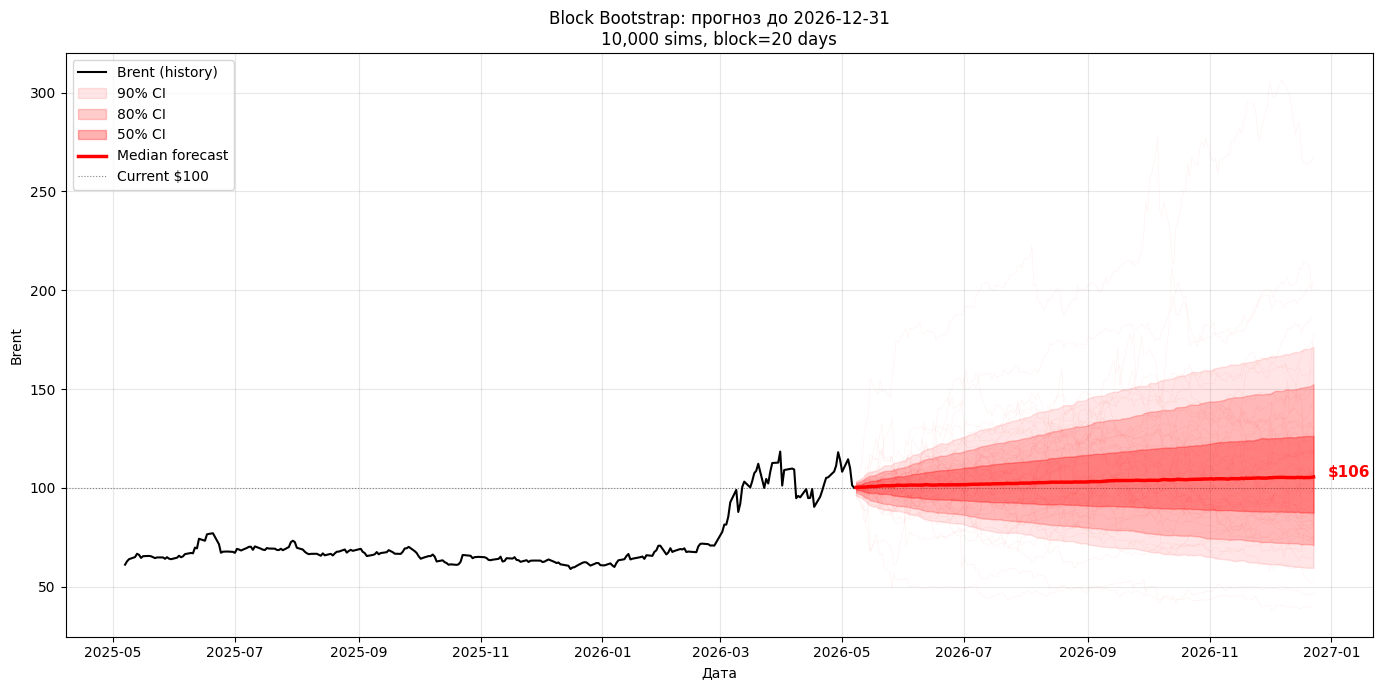

In [20]:
p = np.percentile(paths, [5,10,25,50,75,90,95], axis=0)
hist = daily.loc[last_date - pd.DateOffset(months=12):]

plt.figure(figsize=(14, 7))

plt.plot(hist.index, hist.values, 'k-', linewidth=1.5, label='Brent (history)', zorder=5)

for i in np.random.choice(N_SIMS, 50, replace=False):
    plt.plot(path_dates, paths[i], color='red', alpha=0.05, linewidth=0.5, zorder=1)

plt.fill_between(path_dates, p[0], p[6], color='red', alpha=0.1, label='90% CI', zorder=2)
plt.fill_between(path_dates, p[1], p[5], color='red', alpha=0.2, label='80% CI', zorder=3)
plt.fill_between(path_dates, p[2], p[4], color='red', alpha=0.3, label='50% CI', zorder=4)

plt.plot(path_dates, p[3], 'red', linewidth=2.5, label='Median forecast', zorder=6)

plt.axhline(current_price, color='gray', linewidth=0.8, linestyle=':', label=f'Current ${current_price:.0f}', zorder=2)

plt.annotate(f'${median:.0f}', 
             xy=(path_dates[-1], median),
             xytext=(10, 0), textcoords='offset points',
             fontsize=11, fontweight='bold', color='red')

plt.xlabel('Дата')
plt.ylabel('Brent')
plt.title(f'Block Bootstrap: прогноз до {TARGET_DATE.date()}\n{N_SIMS:,} sims, block={BLOCK_SIZE} days')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

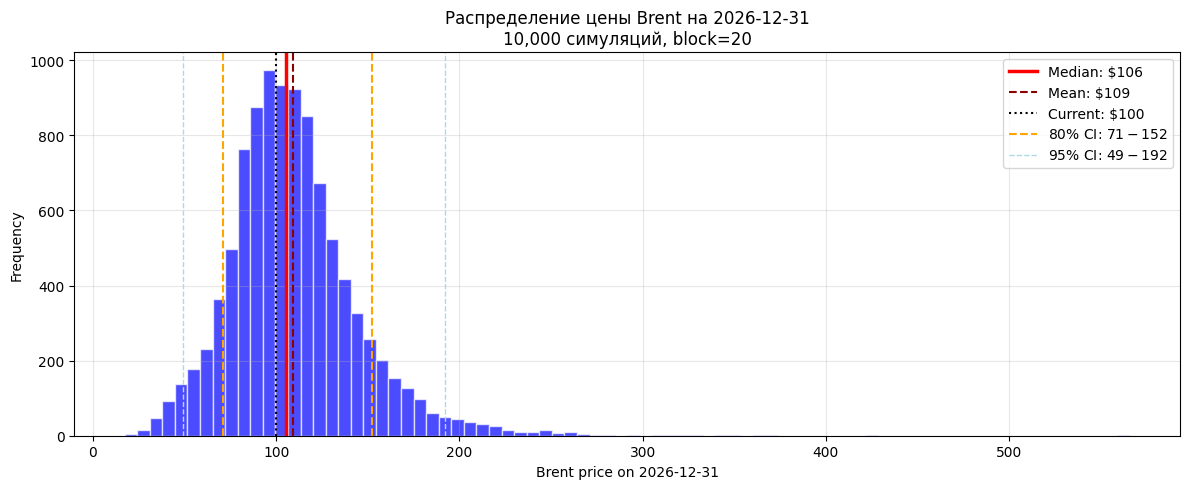

In [21]:
plt.figure(figsize=(12, 5))

plt.hist(terminal_prices, bins=80, color='blue', alpha=0.7, edgecolor='white')
plt.axvline(median, color='red', lw=2.5, label=f'Median: ${median:.0f}')
plt.axvline(mean, color='darkred', lw=1.5, ls='--', label=f'Mean: ${mean:.0f}')
plt.axvline(current_price, color='black', lw=1.5, ls=':', label=f'Current: ${current_price:.0f}')
plt.axvline(ci_80_low, color='orange', lw=1.5, ls='--', label=f'80% CI: ${ci_80_low:.0f}-${ci_80_high:.0f}')
plt.axvline(ci_80_high, color='orange', lw=1.5, ls='--')
plt.axvline(ci_95_low, color='lightblue', lw=1, ls='--', label=f'95% CI: ${ci_95_low:.0f}-${ci_95_high:.0f}')
plt.axvline(ci_95_high, color='lightblue', lw=1, ls='--')

plt.xlabel(f'Brent price on {TARGET_DATE.date()}')
plt.ylabel('Frequency')
plt.title(f'Распределение цены Brent на {TARGET_DATE.date()}\n{N_SIMS:,} симуляций, block={BLOCK_SIZE}')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

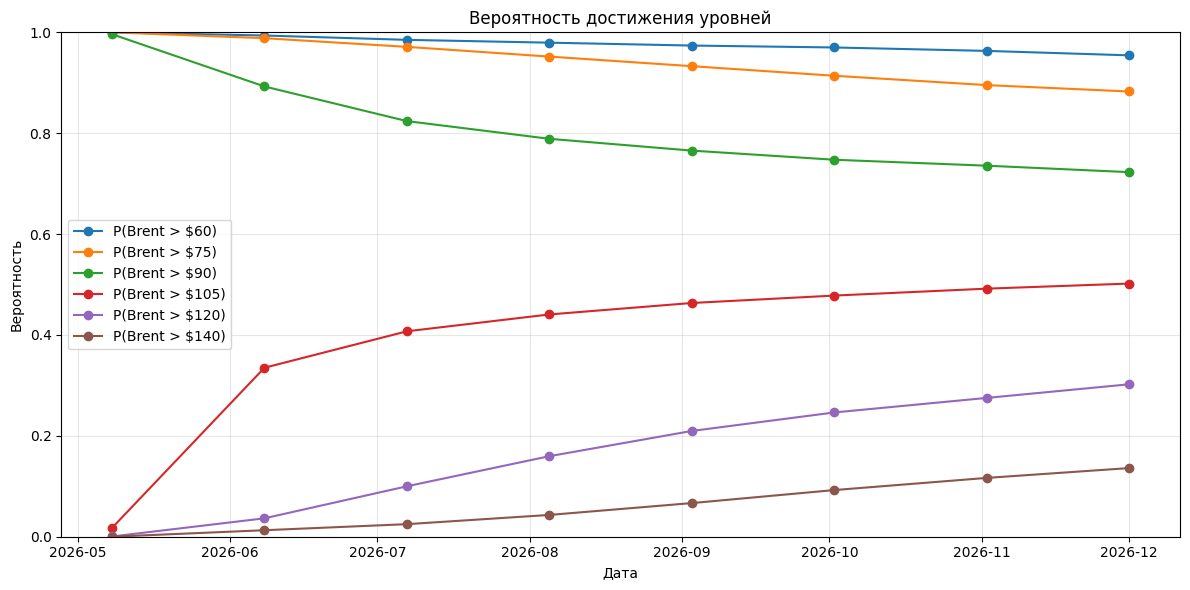

In [22]:
levels = [60, 75, 90, 105, 120, 140]
dates = path_dates[::21]

# Считаем вероятности
probs = []
for i in range(0, len(path_dates), 21):
    row = []
    for l in levels:
        row.append((paths[:, i] > l).mean())
    probs.append(row)

probs = np.array(probs)

plt.figure(figsize=(12, 6))

for i, l in enumerate(levels):
    plt.plot(dates, probs[:, i], 'o-', lw=1.5, label=f'P(Brent > ${l})')

plt.xlabel('Дата')
plt.ylabel('Вероятность')
plt.title(f'Вероятность достижения уровней')
plt.legend(loc='center left')
plt.grid(alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 3. Прогноз до конца 2030 года

In [23]:
TARGET_DATE_2030 = pd.Timestamp("2030-12-31")
N_SIMS_LT = 5_000        # для длинного горизонта меньше
BLOCK_SIZE_LT = 20

# Структурный якорь - долгосрочный уровень нефти, которому она обычно возвращается
# В качестве уровня я поставила 75
ANCHOR = 75
SEED = 42

Для долгосрочного прогноза я использовала block bootstrap и mean reversion.
Как говорила выше, Block bootstrap позволяет сохранять волатильность, автокорреляцию и кризисные режимы - за счёт пересэмплирования исторических блоков доходностей.

На длинном горизонте чистый bootstrap может приводить к нереалистичному накоплению тренда или волатильности, поскольку модель полностью опирается на исторические шоки. Поэтому дополнительно был использован mean reversion механизм, отражающий свойство рынка нефти возвращаться к фундаментально обоснованному уровню цены под влиянием спроса и предложения.

In [24]:
def long_term_forecast(prices, target_date, anchor=75, n_sims=5000, block=20, seed=42):
    np.random.seed(seed)
    
    last = prices.index[-1]
    current = prices.iloc[-1]
    rets = np.log(prices / prices.shift(1)).dropna().values
    days = int(((target_date - last).days) * 252 / 365)
    n_blocks = days // block + 1
    starts = np.arange(len(rets) - block + 1)
    paths = np.zeros((n_sims, days))
    half_life = 504
    kappa = np.log(2) / half_life
    
    log_anchor = np.log(anchor)
    log_current = np.log(current)
    
    for i in range(n_sims):
        blocks = np.random.choice(starts, n_blocks, replace=True)
        rets_path = []
        for b in blocks:
            rets_path.extend(rets[b:b+block])
        rets_path = np.array(rets_path[:days])
        cum = np.cumsum(rets_path)
        log_path_raw = log_current + cum
        
        # Применяем mean reversion (со временем тянет к anchor)
        t = np.arange(1, days + 1)
        deviation = log_path_raw - log_anchor
        mr_factor = np.exp(-kappa * t)
        log_path_mr = log_anchor + deviation * mr_factor
        
        paths[i] = np.exp(log_path_mr)
    
    dates = pd.bdate_range(last + pd.Timedelta(days=1), periods=days)
    
    return paths, dates

In [28]:
paths_lt, dates_lt = long_term_forecast(daily, TARGET_DATE_2030,  anchor=ANCHOR, n_sims=N_SIMS_LT, block=BLOCK_SIZE_LT,seed=SEED)
prices_lt = paths_lt[:, -1]

# Считаем метрики
median_lt = np.median(prices_lt)
mean_lt = np.mean(prices_lt)
c80_low, c80_high = np.percentile(prices_lt, [10, 90])
c95_low, c95_high = np.percentile(prices_lt, [2.5, 97.5])

print(f"Current: ${current_price:.2f}")
print(f"Target: {TARGET_DATE_2030.date()}")
print(f"Anchor: ${ANCHOR}")
print()
print(f"Median: ${median_lt:.2f}")
print(f"Mean: ${mean_lt:.2f}")
print(f"80% CI: ${c80_low:.2f} - ${c80_high:.2f}")
print(f"95% CI: ${c95_low:.2f} - ${c95_high:.2f}")

Current: $100.06
Target: 2030-12-31
Anchor: $75

Median: $85.01
Mean: $85.50
80% CI: $67.46 - $104.17
95% CI: $59.34 - $115.60


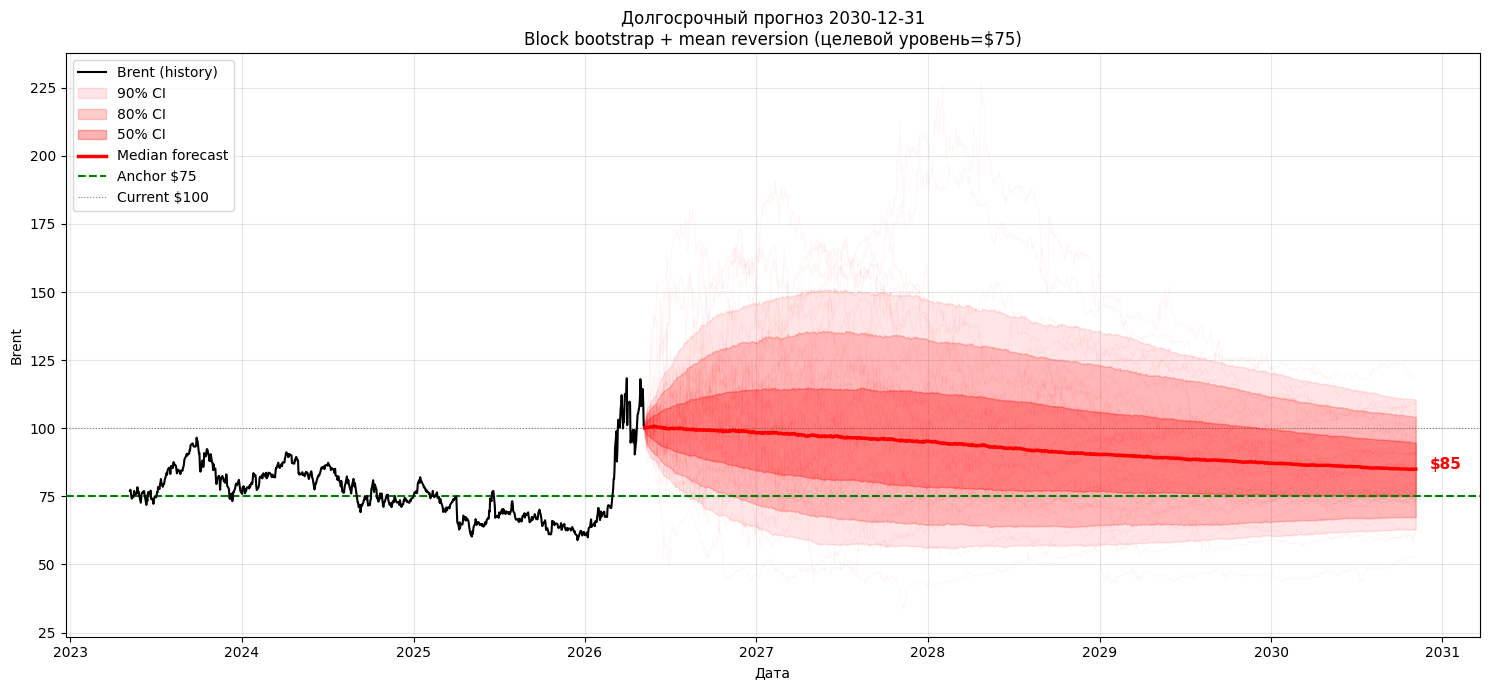

In [ ]:
p_lt = np.percentile(paths_lt, [5,10,25,50,75,90,95], axis=0)
hist = daily.loc[last_date - pd.DateOffset(years=3):]

plt.figure(figsize=(15, 7))

plt.plot(hist.index, hist.values, 'k-', lw=1.5, label='Brent (history)', zorder=5)

for i in np.random.choice(N_SIMS_LT, 50, replace=False):
    plt.plot(dates_lt, paths_lt[i], color='red', alpha=0.04, lw=0.7, zorder=1)

plt.fill_between(dates_lt, p_lt[0], p_lt[6], color='red', alpha=0.1, label='90% CI', zorder=2)
plt.fill_between(dates_lt, p_lt[1], p_lt[5], color='red', alpha=0.2, label='80% CI', zorder=3)
plt.fill_between(dates_lt, p_lt[2], p_lt[4], color='red', alpha=0.3, label='50% CI', zorder=4)

plt.plot(dates_lt, p_lt[3], color='red', lw=2.5, label='Median forecast', zorder=6)

plt.axhline(ANCHOR, color='green', lw=1.5, ls='--', label=f'Anchor ${ANCHOR}', zorder=4)
plt.axhline(current_price, color='gray', lw=0.8, ls=':', label=f'Current ${current_price:.0f}', zorder=2)

plt.annotate(f'${median_lt:.0f}', xy=(dates_lt[-1], median_lt),
             xytext=(10, 0), textcoords='offset points',
             fontsize=11, fontweight='bold', color='red')

plt.xlabel('Дата')
plt.ylabel('Brent')
plt.title(f'Долгосрочный прогноз {TARGET_DATE_2030.date()}\nBlock bootstrap + mean reversion (целевой уровень=${ANCHOR})')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

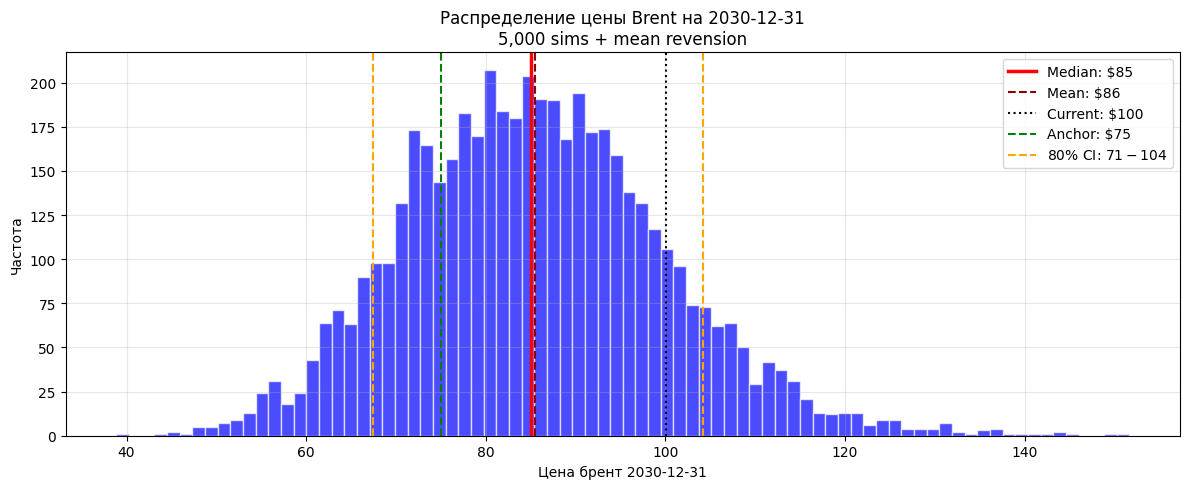

In [ ]:
plt.figure(figsize=(12, 5))

plt.hist(prices_lt, bins=80, color='blue', alpha=0.7, edgecolor='w')

plt.axvline(median_lt, color='r', lw=2.5, label=f'Median: ${median_lt:.0f}')
plt.axvline(mean_lt, color='darkred', lw=1.5, ls='--', label=f'Mean: ${mean_lt:.0f}')
plt.axvline(current_price, color='k', lw=1.5, ls=':', label=f'Current: ${current_price:.0f}')
plt.axvline(ANCHOR, color='g', lw=1.5, ls='--', label=f'Anchor: ${ANCHOR}')
plt.axvline(c80_low, color='orange', lw=1.5, ls='--', label=f'80% CI: ${ci_80_low:.0f}-${c80_high:.0f}')
plt.axvline(c80_high, color='orange', lw=1.5, ls='--')

plt.xlabel(f'Цена брент {TARGET_DATE_2030.date()}')
plt.ylabel('Частота')
plt.title(f'Распределение цены Brent на {TARGET_DATE_2030.date()}\n{N_SIMS_LT:,} sims + mean revension')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()